In [ ]:
# Cell 1: Cài đặt và Import thư viện
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

print("✅ Đã import tất cả thư viện cần thiết cho data processing")
print(f"PyTorch version: {torch.__version__}")

✅ Đã import tất cả thư viện cần thiết cho data processing
PyTorch version: 2.10.0+cpu


In [ ]:
# Cell 2: Mount Google Drive (chỉ chạy 1 lần)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Kiểm tra đường dẫn data raw
base_dir = '/content/drive/MyDrive/HAM10000'
print("✅ Đường dẫn data:", base_dir)
print("Các file/folder trong thư mục:")
print(os.listdir(base_dir))

Mounted at /content/drive
✅ Đường dẫn data: /content/drive/MyDrive/HAM10000
Các file/folder trong thư mục:
['skin-cancer-mnist-ham10000.zip', 'raw', 'class_names.npy']


In [ ]:
# Cell 3: Định nghĩa đường dẫn và load metadata
metadata_path = os.path.join(base_dir, 'raw', 'HAM10000_metadata.csv')

# Load metadata
df = pd.read_csv(metadata_path)
print(f"✅ Đã load metadata: {df.shape[0]} ảnh, {df.shape[1]} cột")
print("Các cột:", df.columns.tolist())
print("\nPhân bố nhãn ban đầu:")
print(df['dx'].value_counts())

# Lưu class names để dùng sau khi train
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])
class_names = le.classes_.tolist()
print("\nClass names:", class_names)
np.save(os.path.join(base_dir, 'class_names.npy'), class_names)  # lưu để load sau

✅ Đã load metadata: 10015 ảnh, 7 cột
Các cột: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Phân bố nhãn ban đầu:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Class names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [ ]:
# Cell 4: Chuẩn bị đường dẫn hình ảnh đầy đủ (part_1 + part_2)
def get_image_path(image_id, base_dir):
    """Tìm đường dẫn ảnh trong 2 thư mục part"""
    for part in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
        path = os.path.join(base_dir, 'raw', part, f"{image_id}.jpg")
        if os.path.exists(path):
            return path
    return None

# Tạo cột image_path
df['image_path'] = df['image_id'].apply(lambda x: get_image_path(x, base_dir))

# Kiểm tra ảnh bị mất (nếu có)
missing = df[df['image_path'].isnull()]
if len(missing) > 0:
    print(f"⚠️ Có {len(missing)} ảnh bị thiếu!")
    df = df.dropna(subset=['image_path'])
else:
    print("✅ Tất cả ảnh đều tìm thấy đường dẫn")

print(f"✅ DataFrame cuối cùng: {len(df)} mẫu")
df.head()

✅ Tất cả ảnh đều tìm thấy đường dẫn
✅ DataFrame cuối cùng: 10015 mẫu


,lesion_id,image_id,dx,dx_type,age,sex,localization,label,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2,/content/drive/MyDrive/HAM10000/raw/HAM10000_i...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2,/content/drive/MyDrive/HAM10000/raw/HAM10000_i...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2,/content/drive/MyDrive/HAM10000/raw/HAM10000_i...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2,/content/drive/MyDrive/HAM10000/raw/HAM10000_i...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2,/content/drive/MyDrive/HAM10000/raw/HAM10000_i...


Phân bố nhãn (raw):
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


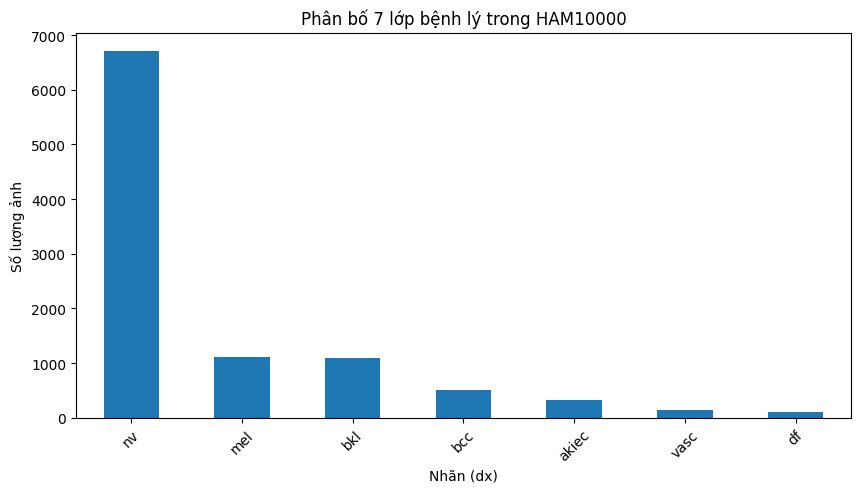

✅ Đã lưu class_distribution.csv


In [ ]:
# Cell 5: Khám phá phân bố dữ liệu (tùy chọn nhưng rất hữu ích)
label_counts = df['dx'].value_counts()
print("Phân bố nhãn (raw):")
print(label_counts)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
label_counts.plot(kind='bar')
plt.title('Phân bố 7 lớp bệnh lý trong HAM10000')
plt.xlabel('Nhãn (dx)')
plt.ylabel('Số lượng ảnh')
plt.xticks(rotation=45)
plt.show()

# Lưu phân bố để reference
label_counts.to_csv(os.path.join(base_dir, 'class_distribution.csv'))
print("✅ Đã lưu class_distribution.csv")

In [ ]:
# Cell 6: Chia dữ liệu train / val / test (stratified - rất quan trọng vì dataset imbalance)
# Tỷ lệ: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

print(f"✅ Chia dữ liệu thành:")
print(f"   Train: {len(train_df)} ảnh ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Val  : {len(val_df)} ảnh ({len(val_df)/len(df)*100:.1f}%)")
print(f"   Test : {len(test_df)} ảnh ({len(test_df)/len(df)*100:.1f}%)")

# Tạo các thư mục con nếu chưa tồn tại
split_dir = os.path.join(base_dir, 'splits')

os.makedirs(split_dir, exist_ok=True)

# Lưu các split vào các thư mục tương ứng để reproducibility
train_df.to_csv(os.path.join(split_dir, 'train_split.csv'), index=False)
val_df.to_csv(os.path.join(split_dir, 'val_split.csv'), index=False)
test_df.to_csv(os.path.join(split_dir, 'test_split.csv'), index=False)


✅ Chia dữ liệu thành:
   Train: 7010 ảnh (70.0%)
   Val  : 1502 ảnh (15.0%)
   Test : 1503 ảnh (15.0%)
✅ Đã lưu 3 file split CSV vào các thư mục con train, val, test
